# 04 — Visualization

Charts built directly from the cleaned data and the query results captured in `reports/query_results.json`. Saved to `visuals/` for reuse in the README and dashboard.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

sns.set_theme(style='whitegrid', palette='deep')
orders = pd.read_csv('data/processed/orders_clean.csv', parse_dates=['order_date'])
valid = orders[(orders['is_valid_price']) ]
products = pd.read_csv('data/processed/products_clean.csv')
regions = pd.read_csv('data/processed/regions_clean.csv')
customers = pd.read_csv('data/processed/customers_clean.csv')
rfm = pd.read_csv('data/processed/rfm_segments.csv')
results = json.load(open('reports/query_results.json'))

## Monthly revenue trend

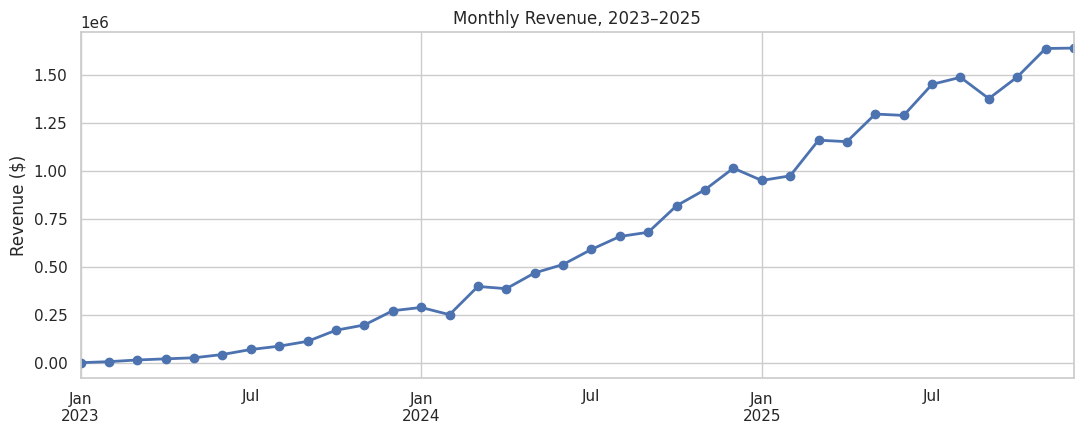

In [2]:
monthly = valid.set_index('order_date').resample('MS')['revenue'].sum()
fig, ax = plt.subplots(figsize=(11,4.5))
monthly.plot(ax=ax, marker='o', linewidth=2)
ax.set_title('Monthly Revenue, 2023–2025')
ax.set_ylabel('Revenue ($)')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig('visuals/monthly_revenue_trend.png', dpi=140)
plt.show()

## Revenue and margin by category

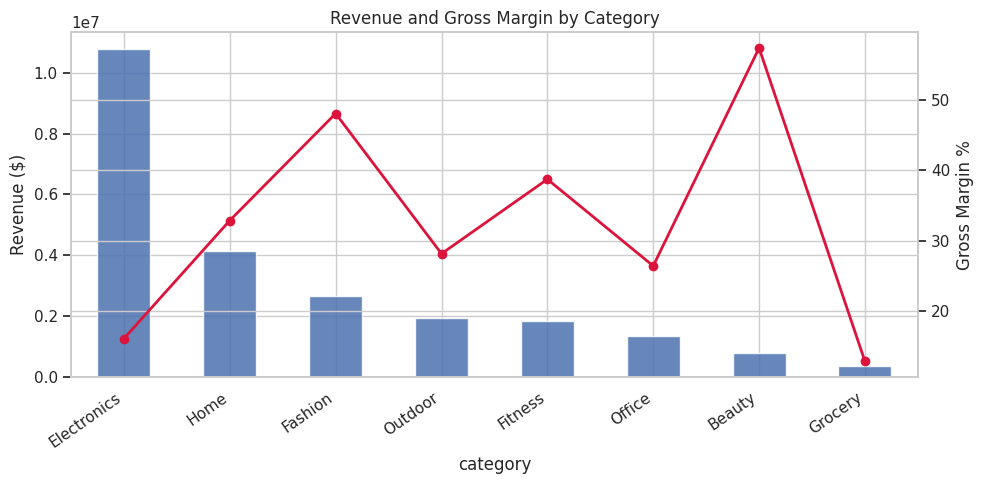

In [3]:
cat = valid.merge(products[['product_id','category']], on='product_id')
cat_g = cat.groupby('category').agg(revenue=('revenue','sum'), profit=('gross_profit','sum')).sort_values('revenue', ascending=False)
cat_g['margin_pct'] = cat_g['profit'] / cat_g['revenue'] * 100

fig, ax1 = plt.subplots(figsize=(10,5))
cat_g['revenue'].plot(kind='bar', ax=ax1, color=sns.color_palette('deep')[0], alpha=0.85)
ax1.set_ylabel('Revenue ($)')
ax2 = ax1.twinx()
ax2.plot(range(len(cat_g)), cat_g['margin_pct'], color='crimson', marker='o', linewidth=2)
ax2.set_ylabel('Gross Margin %')
ax1.set_title('Revenue and Gross Margin by Category')
ax1.set_xticklabels(cat_g.index, rotation=35, ha='right')
plt.tight_layout()
plt.savefig('visuals/category_revenue_margin.png', dpi=140)
plt.show()

## RFM segment value

/tmp/ipykernel_671/920539956.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=seg_val.index, y=seg_val['mean'], ax=ax, palette='deep')


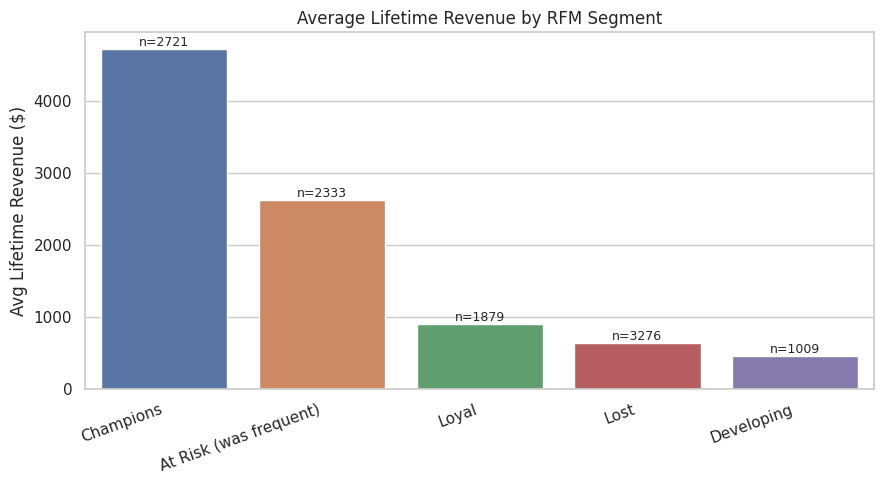

In [4]:
seg_val = rfm.groupby('segment')['monetary'].agg(['mean','count']).sort_values('mean', ascending=False)
fig, ax = plt.subplots(figsize=(9,5))
sns.barplot(x=seg_val.index, y=seg_val['mean'], ax=ax, palette='deep')
for i, (m, c) in enumerate(zip(seg_val['mean'], seg_val['count'])):
    ax.text(i, m, f'n={c}', ha='center', va='bottom', fontsize=9)
ax.set_title('Average Lifetime Revenue by RFM Segment')
ax.set_ylabel('Avg Lifetime Revenue ($)')
ax.set_xlabel('')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('visuals/rfm_segment_value.png', dpi=140)
plt.show()

## Marketing: CAC vs. revenue efficiency by channel

/tmp/ipykernel_671/3575683052.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=combined.index, y=combined['cac'], ax=axes[0], palette='deep')
/tmp/ipykernel_671/3575683052.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=combined.index, y=combined['revenue_per_dollar_spent'], ax=axes[1], palette='rocket')


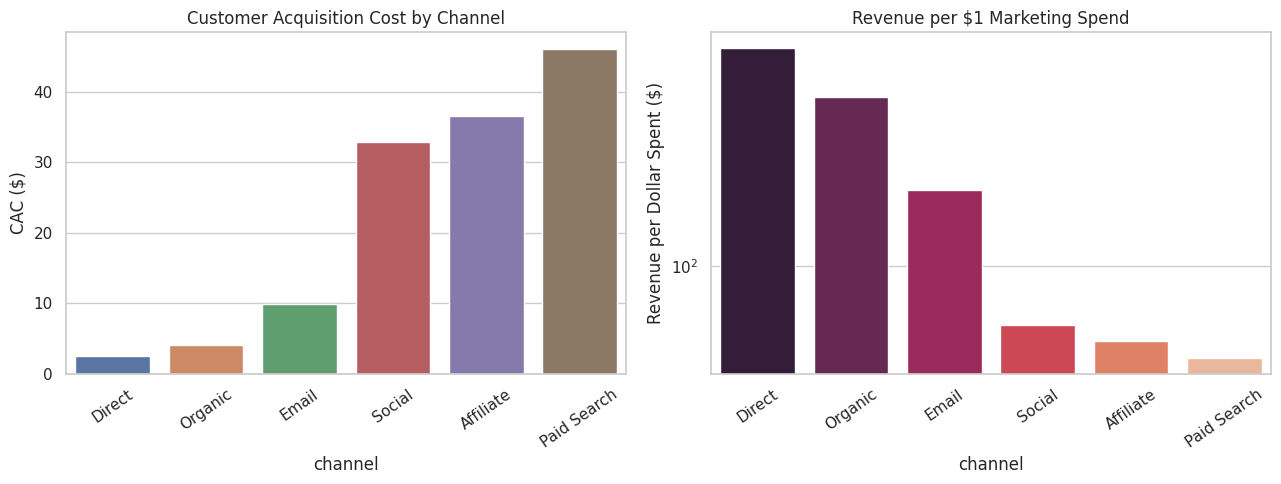

In [5]:
cac_df = pd.DataFrame(results['Q13']['sample']).set_index('channel')
eff_df = pd.DataFrame(results['Q14']['sample']).set_index('channel')
combined = cac_df[['cac']].join(eff_df[['revenue_per_dollar_spent']]).sort_values('cac')

fig, axes = plt.subplots(1, 2, figsize=(13,5))
sns.barplot(x=combined.index, y=combined['cac'], ax=axes[0], palette='deep')
axes[0].set_title('Customer Acquisition Cost by Channel')
axes[0].set_ylabel('CAC ($)')
axes[0].tick_params(axis='x', rotation=35)
sns.barplot(x=combined.index, y=combined['revenue_per_dollar_spent'], ax=axes[1], palette='rocket')
axes[1].set_title('Revenue per $1 Marketing Spend')
axes[1].set_ylabel('Revenue per Dollar Spent ($)')
axes[1].set_yscale('log')
axes[1].tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.savefig('visuals/cac_vs_efficiency.png', dpi=140)
plt.show()

## Return rate by category

/tmp/ipykernel_671/2881777465.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='category', y='return_rate_pct', data=ret_df, ax=ax, palette='flare')


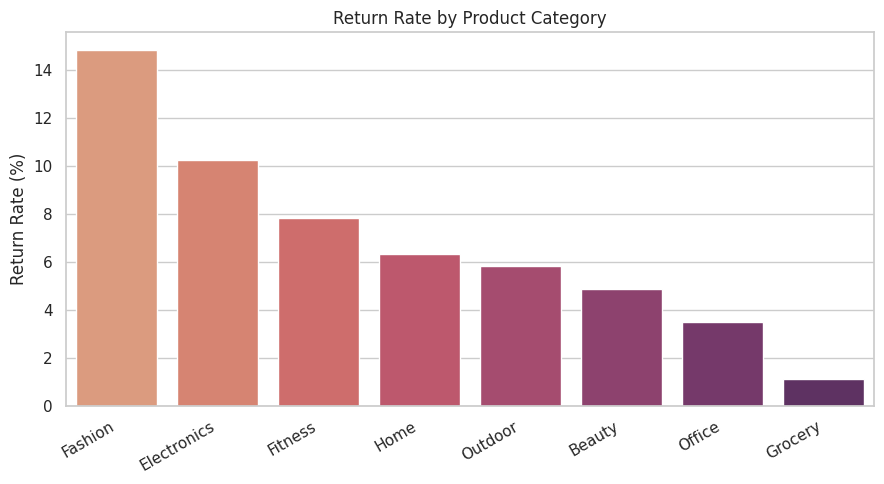

In [6]:
ret_df = pd.DataFrame(results['Q15']['sample']).sort_values('return_rate_pct', ascending=False)
fig, ax = plt.subplots(figsize=(9,5))
sns.barplot(x='category', y='return_rate_pct', data=ret_df, ax=ax, palette='flare')
ax.set_title('Return Rate by Product Category')
ax.set_ylabel('Return Rate (%)')
ax.set_xlabel('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('visuals/return_rate_by_category.png', dpi=140)
plt.show()

## Enterprise vs. Small Business vs. Consumer economics

/tmp/ipykernel_671/3280385218.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='segment', y='gross_margin_pct', data=seg_df, ax=axes[0], palette='deep')
/tmp/ipykernel_671/3280385218.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='segment', y='revenue_per_customer', data=seg_df, ax=axes[1], palette='deep')


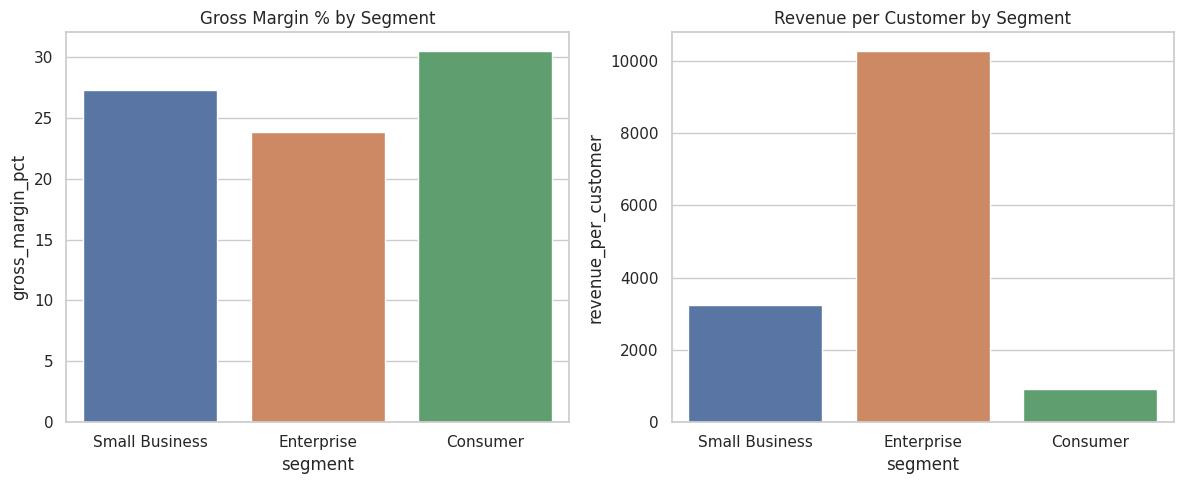

In [7]:
seg_df = pd.DataFrame(results['Q18']['sample'])
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.barplot(x='segment', y='gross_margin_pct', data=seg_df, ax=axes[0], palette='deep')
axes[0].set_title('Gross Margin % by Segment')
sns.barplot(x='segment', y='revenue_per_customer', data=seg_df, ax=axes[1], palette='deep')
axes[1].set_title('Revenue per Customer by Segment')
plt.tight_layout()
plt.savefig('visuals/segment_economics.png', dpi=140)
plt.show()